# 1) Loading data

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_store = pd.read_csv("../data/stores.csv")
df_category = pd.read_csv("../data/categories.csv")
df_product = pd.read_csv("../data/products.csv")
df_review = pd.read_csv("../data/reviews.csv")

# 2) Analysis sample size

In [33]:
print("STORE:", df_store.shape)
print("CATEGORY:", df_category.shape)
print("PRODUCT:", df_product.shape)
print("REVIEW:", df_review.shape)

STORE: (1446, 5)
CATEGORY: (497, 4)
PRODUCT: (55883, 14)
REVIEW: (158126, 8)


# 3) Analysis structure data

## Columns name and type of data

In [34]:
print("===== STORE INFO =====")
print(df_store.info())

print("\n===== CATEGORY INFO =====")
print(df_category.info())

print("\n===== PRODUCT INFO =====")
print(df_product.info())

print("\n===== REVIEW INFO =====")
print(df_review.info())

===== STORE INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1446 entries, 0 to 1445
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   store_id         1446 non-null   int64  
 1   store_name       1446 non-null   object 
 2   store_rating     1446 non-null   float64
 3   follower_count   1446 non-null   int64  
 4   source_category  1446 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 56.6+ KB
None

===== CATEGORY INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   category_id      497 non-null    int64 
 1   category_name    497 non-null    object
 2   parent_category  492 non-null    object
 3   source_category  497 non-null    object
dtypes: int64(1), object(3)
memory usage: 15.7+ KB
None

===== PRODUCT INFO ====

## Checking missing values

In [35]:
print("\nMissing values:")
print(df_store.isnull().sum())

print(df_category.isnull().sum())
print(df_product.isnull().sum())
print(df_review.isnull().sum())


Missing values:
store_id           0
store_name         0
store_rating       0
follower_count     0
source_category    0
dtype: int64
category_id        0
category_name      0
parent_category    5
source_category    0
dtype: int64
product_id            0
store_id            860
category_id           0
product_name          0
product_url           0
brand                 2
description          53
price                 0
original_price        0
discount_percent      0
sold_count            0
rating_avg            0
review_count          0
source_category       0
dtype: int64
review_id          0
product_id         0
user_name          0
rating             0
review_text        0
like_count         0
review_date        0
source_category    0
dtype: int64


# 4) Thống kê mô tả các biến số

In [36]:
print(df_store[['store_rating','follower_count']].describe())
print(df_product['price'].describe())
print(df_review[['rating','like_count']].describe())

       store_rating  follower_count
count   1446.000000     1446.000000
mean       3.222462      785.340941
std        2.018953    14132.360500
min        0.000000        0.000000
25%        0.000000        0.000000
50%        4.340500        2.000000
75%        4.644325       73.500000
max        5.000000   512930.000000
count    5.588300e+04
mean     2.377133e+06
std      1.112896e+07
min      1.800000e+03
25%      8.900000e+04
50%      3.096000e+05
75%      1.250000e+06
max      8.178840e+08
Name: price, dtype: float64
              rating     like_count
count  158126.000000  158126.000000
mean        4.681355       0.211591
std         0.837277       1.948833
min         1.000000       0.000000
25%         5.000000       0.000000
50%         5.000000       0.000000
75%         5.000000       0.000000
max         5.000000     289.000000


# 5) Thống kê các biến quan trọng

## Thống kê giá sản phẩm

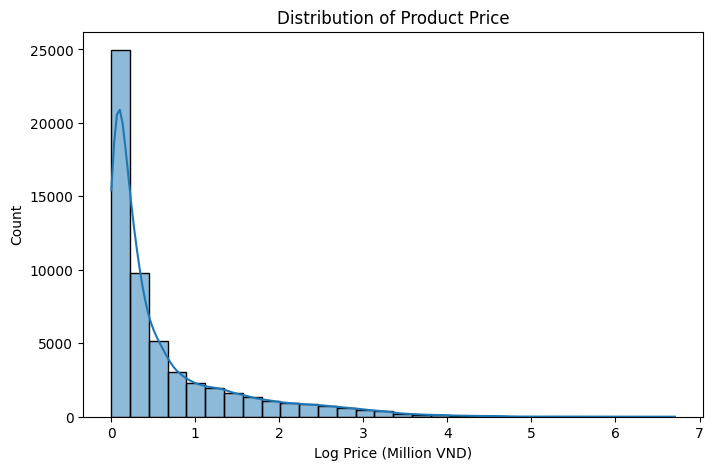

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df_product["price"] / 1e6), bins=30, kde=True)
#sns.histplot(df_product["price"], bins=30, kde=True)
plt.title("Distribution of Product Price")
plt.xlabel("Log Price (Million VND)")
plt.show()

## Phân số số lượng bán

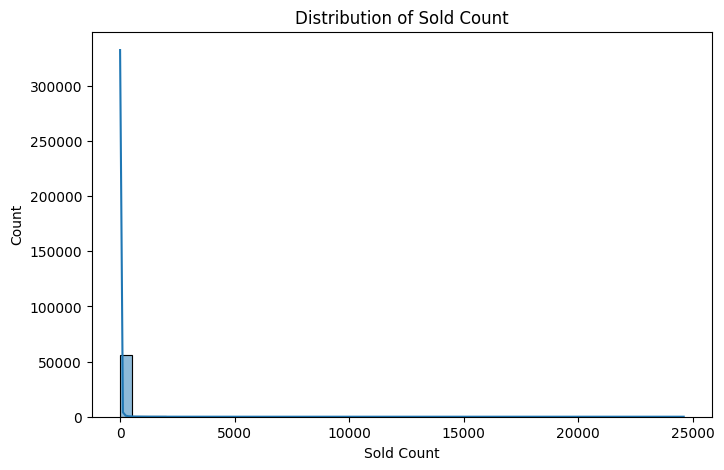

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df_product["sold_count"], bins=[0,500,2000,3000,4000,5000], kde=True)
plt.title("Distribution of Sold Count")
plt.xlabel("Sold Count")
plt.show()

## Phân bố rating cửa hàng

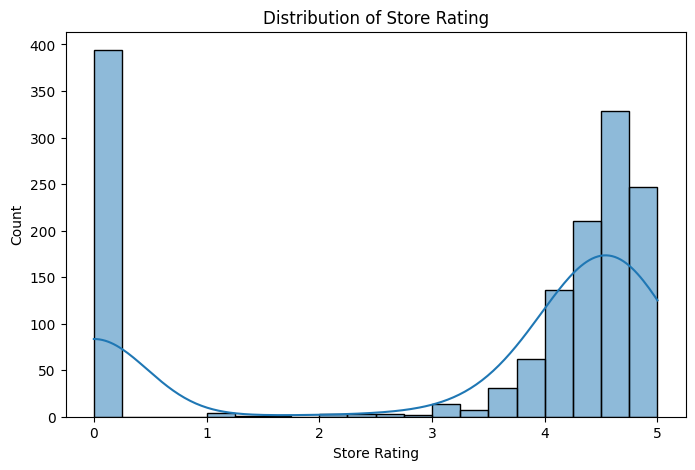

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df_store["store_rating"], bins=20, kde=True)
plt.title("Distribution of Store Rating")
plt.xlabel("Store Rating")
plt.show()

## Phân bố rating sản phẩm

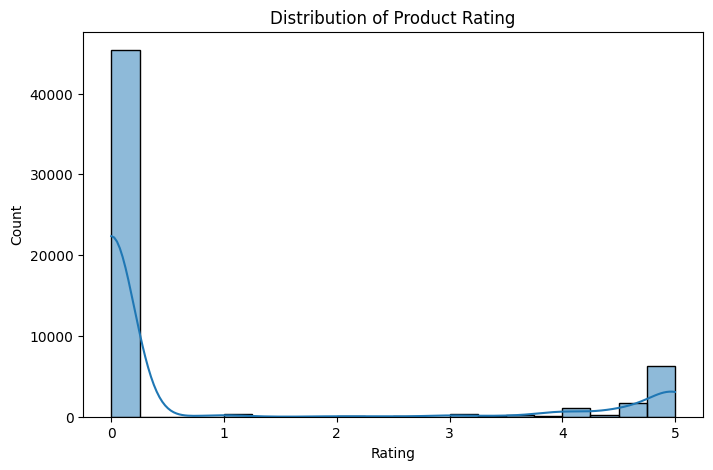

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df_product["rating_avg"], bins=20, kde=True)
plt.title("Distribution of Product Rating")
plt.xlabel("Rating")
plt.show()

# 6) Phân bố biến phân loại

In [41]:
df_cat_product = df_product.merge(df_category, on="category_id", how="left")

cat_count = (
    df_cat_product.groupby(["parent_category", "category_name"])
    .size()
    .reset_index(name="product_count")
)

cat_count["parent_category"] = cat_count["parent_category"].fillna("Tiki Categories")

fig = px.treemap(
    cat_count,
    path=["parent_category", "category_name"],
    values="product_count",
    title="Category Treemap"
)

fig.show()


## Số lượng sản phẩm theo danh mục

In [42]:
df_product_category = df_product.merge(
    df_category,
    on="category_id",
    how="left"
)

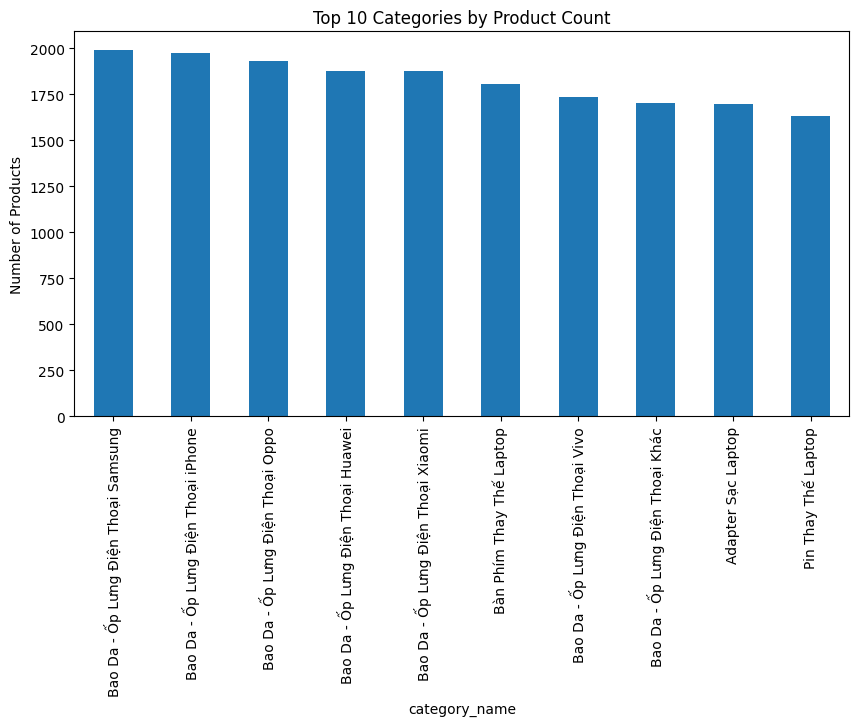

In [43]:
plt.figure(figsize=(10,5))
df_product_category["category_name"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Categories by Product Count")
plt.ylabel("Number of Products")
plt.show()